# Task 2 — Hybrid HAPS Offloading Strategy

## Scenario
$M$ sensing nodes generate tasks at rate $\lambda$ [tasks/s]. Each task is offloaded to the HAPS with probability **$p$**, else processed locally.

## Completion time components (lab tip)
| Path | Components |
|------|------------|
| **Local** | $W_{\mathrm{loc}} + C/f_{\mathrm{loc}}$ |
| **HAPS** | $t_{\mathrm{tx}} + t_{\mathrm{prop}} + W_{\mathrm{haps}} + C/f_{\mathrm{haps}}$ |

with $t_{\mathrm{tx}}=L/R_{\mathrm{ul}}$, $T_{\mathrm{serv}}=C/f$, $C\sim\mathrm{Exp}(\bar{C})$ (tips.md).

## Parameters (tips.md)
| Parameter | Value |
|-----------|-------|
| $M=10$, $\lambda=2$ tasks/s/node, $N=2$ HAPS servers | |
| $f_{\mathrm{loc}}=10^8$, $f_{\mathrm{haps}}=10^9$ cycles/s | |
| **Ks**: $\bar{C}=5\times10^6$, $L=2$ Mbit, $D_{\max}=0.5$ s | |
| **Kt**: $\bar{C}=5\times10^7$, $L=10$ Mbit, $D_{\max}=10$ s | |
| Simulation | `SIM_TIME=50,000` s, warm-up `10,000` s |
| $p$ sweep | $\{0,\,0.25,\,0.5,\,0.75,\,1\}$ |

## Tasks
- **2.a** Sweep $p$ for **Ks-only** and **Kt-only** traffic
- **2.b** Beneficial vs detrimental offloading regions (delay + energy)
- **2.c** Compare extremes $p=0$ vs $p=1$

> **Notebook layout:** simulation cell → plot cells (inline figures) → observation reports.


In [1]:
import random
import numpy as np
from queue import PriorityQueue

# PARAMETERS (tips.md) — fast permanent settings
M          = 10
LAM        = 2.0
F_LOC      = 1e8
F_HAPS     = 1e9
B_LOC      = 20
N_HAPS     = 2
B_HAPS     = 200
R_UL       = 10e6
T_PROP     = 0.002
SIM_TIME   = 50_000            # fast: 50k s total
WARMUP_T   = 10_000            # discard first 10k s
SEED       = 42
P_TX       = 0.5
P_LOC      = 1.0

TASKS = {
    'Ks': {'L': 2e6,  'C_mean': 5e6,  'Dmax': 0.5},
    'Kt': {'L': 10e6, 'C_mean': 5e7,  'Dmax': 10.0},
}

P_VALUES = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

CFG = (
    f"M={M} nodes | lambda={LAM} tasks/s/node | N={N_HAPS} HAPS servers | "
    f"f_loc={F_LOC:.0e} cyc/s | f_haps={F_HAPS:.0e} cyc/s | "
    f"R_ul={R_UL/1e6:.0f} Mbit/s | t_prop={T_PROP*1e3:.1f} ms | "
    f"SIM_TIME={SIM_TIME:,} s | warm-up={WARMUP_T:,} s | "
    f"p in {{0, 0.25, 0.5, 0.75, 1}}"
)


def sample_proc(C_mean, F, rng):
    return rng.expovariate(1.0 / C_mean) / F


def simulate(p, task_class, seed=SEED):
    rng = random.Random(seed)
    cfg = TASKS[task_class]
    L, C_mean, Dmax = cfg['L'], cfg['C_mean'], cfg['Dmax']
    t_tx = L / R_UL

    loc_q = [[] for _ in range(M)]
    loc_busy = [False] * M
    loc_n = [0] * M
    hap_q = []
    hap_busy = [False] * N_HAPS
    hap_n = 0
    hap_old_t = 0.0
    hap_busy_area = 0.0
    hap_busy_old_t = 0.0
    loc_busy_area = [0.0] * M
    loc_busy_old_t = [0.0] * M

    FES = PriorityQueue()
    time = 0.0
    for m in range(M):
        FES.put((rng.expovariate(LAM), 'arr', m))

    stats = dict(
        loc_n=0, hap_n=0, loc_d=0.0, hap_d=0.0,
        loc_viol=0, hap_viol=0, loc_drop=0, hap_drop=0,
        loc_arr=0, hap_arr=0, e_loc=0.0, e_tx=0.0,
        comp_tx=0.0, comp_prop=0.0, comp_wq=0.0, comp_proc=0.0, comp_hap_n=0,
    )

    def hap_integrate(t):
        nonlocal hap_busy_area, hap_busy_old_t
        hap_busy_area += sum(hap_busy) * (t - hap_busy_old_t)
        hap_busy_old_t = t

    def loc_integrate(m, t):
        loc_busy_area[m] += (1 if loc_busy[m] else 0) * (t - loc_busy_old_t[m])
        loc_busy_old_t[m] = t

    def record_loc(t, gen_t, proc_t):
        if t < WARMUP_T:
            return
        d = t - gen_t
        stats['loc_n'] += 1
        stats['loc_d'] += d
        if d > Dmax:
            stats['loc_viol'] += 1
        stats['e_loc'] += P_LOC * proc_t

    def record_hap(t, gen_t, arrive_haps, proc_start, proc_t):
        if t < WARMUP_T:
            return
        d = t - gen_t
        stats['hap_n'] += 1
        stats['hap_d'] += d
        if d > Dmax:
            stats['hap_viol'] += 1
        stats['e_tx'] += P_TX * (L / 1e6)
        stats['comp_tx'] += t_tx
        stats['comp_prop'] += T_PROP
        stats['comp_wq'] += max(0.0, proc_start - arrive_haps)
        stats['comp_proc'] += proc_t
        stats['comp_hap_n'] += 1

    def on_arrival(t, m):
        nonlocal hap_n
        FES.put((t + rng.expovariate(LAM), 'arr', m))
        if rng.random() < p:
            stats['hap_arr'] += 1
            arrive_haps = t + t_tx + T_PROP
            hap_integrate(t)
            waiting = max(0, hap_n - sum(hap_busy))
            if waiting >= B_HAPS:
                stats['hap_drop'] += 1
                return
            hap_n += 1
            srv = next((i for i, b in enumerate(hap_busy) if not b), None)
            if srv is not None:
                hap_busy[srv] = True
                proc_t = sample_proc(C_mean, F_HAPS, rng)
                proc_start = max(t, arrive_haps)
                FES.put((proc_start + proc_t, 'hap_dep', srv, t, arrive_haps, proc_start, proc_t))
            else:
                hap_q.append((arrive_haps, t))
        else:
            stats['loc_arr'] += 1
            loc_integrate(m, t)
            q_len = loc_n[m] - (1 if loc_busy[m] else 0)
            if q_len >= B_LOC:
                stats['loc_drop'] += 1
                return
            loc_n[m] += 1
            loc_q[m].append(t)
            if not loc_busy[m]:
                loc_busy[m] = True
                gen_t = loc_q[m].pop(0)
                proc_t = sample_proc(C_mean, F_LOC, rng)
                FES.put((t + proc_t, 'loc_dep', m, gen_t, proc_t))

    def on_loc_dep(t, m, gen_t, proc_t):
        loc_integrate(m, t)
        loc_n[m] -= 1
        record_loc(t, gen_t, proc_t)
        if loc_q[m]:
            gen_t2 = loc_q[m].pop(0)
            proc_t2 = sample_proc(C_mean, F_LOC, rng)
            FES.put((t + proc_t2, 'loc_dep', m, gen_t2, proc_t2))
        else:
            loc_busy[m] = False

    def on_hap_dep(t, srv, gen_t, arrive_haps, proc_start, proc_t):
        nonlocal hap_n
        hap_integrate(t)
        hap_n -= 1
        record_hap(t, gen_t, arrive_haps, proc_start, proc_t)
        if hap_q:
            arrive_haps2, gen_t2 = hap_q.pop(0)
            proc_t2 = sample_proc(C_mean, F_HAPS, rng)
            proc_start2 = max(t, arrive_haps2)
            hap_busy[srv] = True
            FES.put((proc_start2 + proc_t2, 'hap_dep', srv, gen_t2, arrive_haps2, proc_start2, proc_t2))
        else:
            hap_busy[srv] = False

    while time < SIM_TIME:
        ev = FES.get()
        time = ev[0]
        kind = ev[1]
        if kind == 'arr':
            on_arrival(time, ev[2])
        elif kind == 'loc_dep':
            on_loc_dep(time, ev[2], ev[3], ev[4])
        elif kind == 'hap_dep':
            on_hap_dep(time, ev[2], ev[3], ev[4], ev[5], ev[6])

    hap_integrate(SIM_TIME)
    for m in range(M):
        loc_integrate(m, SIM_TIME)

    obs_t = SIM_TIME - WARMUP_T
    total = stats['loc_n'] + stats['hap_n']

    def safe_div(a, b):
        return a / b if b else float('nan')

    return {
        'ET_avg': safe_div(stats['loc_d'] + stats['hap_d'], total),
        'ET_loc': safe_div(stats['loc_d'], stats['loc_n']),
        'ET_hap': safe_div(stats['hap_d'], stats['hap_n']),
        'viol_prob': safe_div(stats['loc_viol'] + stats['hap_viol'], total),
        'qos_rate': 1 - safe_div(stats['loc_viol'] + stats['hap_viol'], total) if total else float('nan'),
        'drop_prob': safe_div(stats['loc_drop'] + stats['hap_drop'], stats['loc_arr'] + stats['hap_arr']),
        'throughput': total / obs_t,
        'loc_util': sum(loc_busy_area) / (M * obs_t),
        'hap_util': hap_busy_area / (N_HAPS * obs_t),
        'E_total': safe_div(stats['e_loc'] + stats['e_tx'], total),
        'd_tx': safe_div(stats['comp_tx'], stats['comp_hap_n']),
        'd_prop': safe_div(stats['comp_prop'], stats['comp_hap_n']),
        'd_wq': safe_div(stats['comp_wq'], stats['comp_hap_n']),
        'd_proc': safe_div(stats['comp_proc'], stats['comp_hap_n']),
    }


KEYS = [
    'ET_avg', 'ET_loc', 'ET_hap', 'viol_prob', 'qos_rate', 'drop_prob',
    'throughput', 'loc_util', 'hap_util', 'E_total', 'd_tx', 'd_prop', 'd_wq', 'd_proc',
]
results = {tc: {k: [] for k in KEYS} for tc in ['Ks', 'Kt']}

print("Running p-sweep (fast settings)...")
for tc in ['Ks', 'Kt']:
    cfg = TASKS[tc]
    print(f"\n-- Task class {tc} | L={cfg['L']/1e6:.0f} Mbit | C_mean={cfg['C_mean']:.0e} cyc | Dmax={cfg['Dmax']} s --")
    print(f"{'p':>5} | {'E[T]':>7} | {'E[T]_loc':>8} | {'E[T]_hap':>8} | {'QoS':>6} | {'Drop':>6} | {'TP':>6}")
    print("-" * 62)
    for p in P_VALUES:
        r = simulate(float(p), tc)
        for k in KEYS:
            results[tc][k].append(r[k])
        et_loc = r['ET_loc']
        et_hap = r['ET_hap']
        print(
            f"{p:>5.2f} | {r['ET_avg']:>7.3f} | "
            f"{et_loc:>8.3f} | {et_hap:>8.3f} | "
            f"{r['qos_rate']:>6.3f} | {r['drop_prob']:>6.3f} | {r['throughput']:>6.3f}"
        )

for tc in ['Ks', 'Kt']:
    cm = TASKS[tc]['C_mean']
    print(f"\n{tc} mean proc: local={cm/F_LOC:.3f}s  HAPS={cm/F_HAPS:.4f}s  t_tx={TASKS[tc]['L']/R_UL:.3f}s")
print(f"\nConfiguration: {CFG}")



Running p-sweep (fast settings)...

-- Task class Ks | L=2 Mbit | C_mean=5e+06 cyc | Dmax=0.5 s --
    p |    E[T] | E[T]_loc | E[T]_hap |    QoS |   Drop |     TP
--------------------------------------------------------------


 0.00 |   0.055 |    0.055 |      nan |  1.000 |  0.000 | 19.998


 0.25 |   0.092 |    0.054 |    0.207 |  1.000 |  0.000 | 20.003


 0.50 |   0.130 |    0.053 |    0.207 |  1.000 |  0.000 | 20.005


 0.75 |   0.168 |    0.051 |    0.207 |  1.000 |  0.000 | 20.013


...

 0.00 |   5.502 |    5.502 |      nan |  0.889 |  0.046 | 19.101


 0.25 |   1.761 |    1.997 |    1.053 |  0.996 |  0.000 | 20.022


 0.50 |   1.031 |    1.006 |    1.055 |  1.000 |  0.000 | 20.044


 0.75 |   0.962 |    0.665 |    1.060 |  1.000 |  0.000 | 20.016


 1.00 |   1.069 |      nan |    1.069 |  1.000 |  0.000 | 20.014

Ks mean proc: local=0.050s  HAPS=0.0050s  t_tx=0.200s

Kt mean proc: local=0.500s  HAPS=0.0500s  t_tx=1.000s

Configuration: M=10 nodes | lambda=2.0 tasks/s/node | N=2 HAPS servers | f_loc=1e+08 cyc/s | f_haps=1e+09 cyc/s | R_ul=10 Mbit/s | t_prop=2.0 ms | SIM_TIME=50,000 s | warm-up=10,000 s | p in {0, 0.25, 0.5, 0.75, 1}


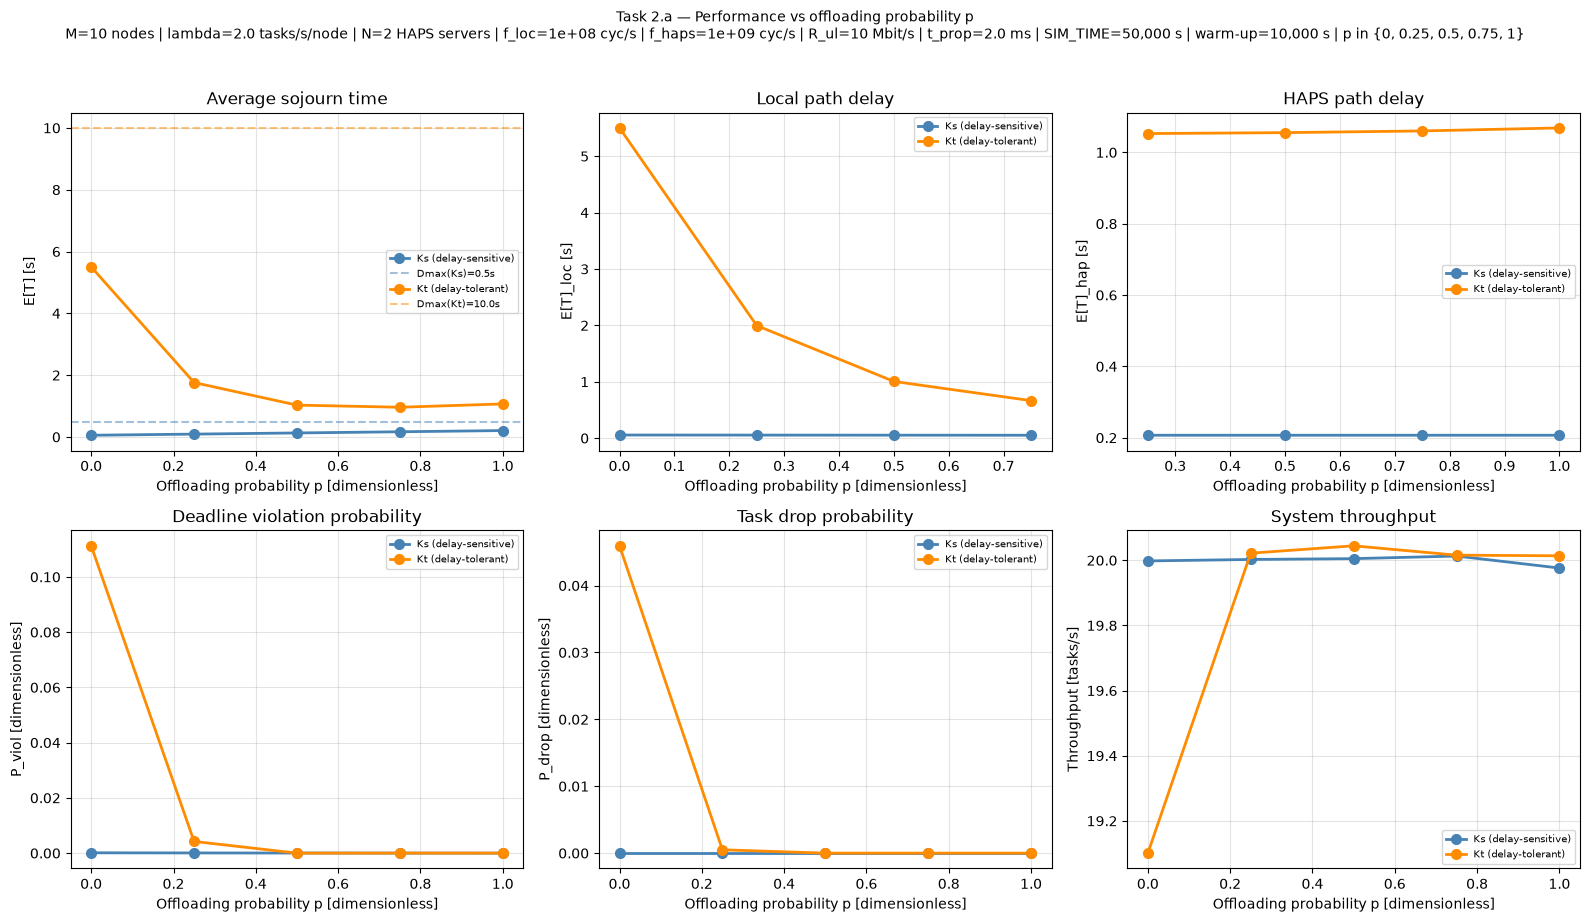

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

colors = {'Ks': 'steelblue', 'Kt': 'darkorange'}
labels = {'Ks': 'Ks (delay-sensitive)', 'Kt': 'Kt (delay-tolerant)'}

# Task 2.a — plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = [
    ('ET_avg',    'E[T] [s]',               'Average sojourn time'),
    ('ET_loc',    'E[T]_loc [s]',           'Local path delay'),
    ('ET_hap',    'E[T]_hap [s]',           'HAPS path delay'),
    ('viol_prob', 'P_viol [dimensionless]', 'Deadline violation probability'),
    ('drop_prob', 'P_drop [dimensionless]', 'Task drop probability'),
    ('throughput','Throughput [tasks/s]',   'System throughput'),
]
for ax, (key, ylab, title) in zip(axes.flat, metrics):
    for tc in ['Ks', 'Kt']:
        ax.plot(P_VALUES, results[tc][key], 'o-', color=colors[tc], lw=2, ms=7, label=labels[tc])
        if key == 'ET_avg':
            ax.axhline(TASKS[tc]['Dmax'], color=colors[tc], ls='--', alpha=0.5,
                       label=f"Dmax({tc})={TASKS[tc]['Dmax']}s")
    ax.set_xlabel('Offloading probability p [dimensionless]')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.35)
fig.suptitle(f"Task 2.a — Performance vs offloading probability p\n{CFG}", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('task2a_offloading.png', dpi=150, bbox_inches='tight')
plt.show()



## Task 2.a — Observations and Report

The simulation sweeps offloading probability $p$ over $\{0, 0.25, 0.5, 0.75, 1\}$ for two isolated traffic classes: **Ks** (light, delay-sensitive) and **Kt** (heavy, delay-tolerant). With $M=10$ nodes at $\lambda=2$ tasks/s each, the local utilisation at $p=0$ is already very different between the two classes — roughly 0.1 for Ks versus 1.0 for Kt — so the same offloading policy should not be expected to work for both.

### Ks — offloading only adds cost

For Ks, the plots show a steady, almost linear increase in mean completion time as $p$ rises, while QoS stays at 100 % and there are no drops at any point. This makes sense because the local node is not congested: at $p=0$, simulated $E[T]$ agrees with the M/M/1 prediction for $\rho_{\mathrm{loc}}=0.1$, so queueing is negligible. The HAPS path is faster at compute time, but each offloaded task must still pay a fixed transmission penalty ($t_{\mathrm{tx}}$ dominates over the HAPS processing gain). Since $E[T]_{\mathrm{hap}}$ stays flat across the sweep, the average delay is essentially a weighted mix of a fast local path and a slower remote one — offloading more tasks simply shifts the mix toward the worse option. The best choice is therefore **$p=0$**: there is no local bottleneck to fix.

### Kt — hybrid offloading is necessary

Kt behaves in the opposite way. At $p=0$, the local server is saturated ($\rho_{\mathrm{loc}}=1$), which drives up queueing delay, causes buffer drops, and reduces throughput below the offered load. QoS falls below 90 % even though the deadline is relatively loose. Introducing even a small offloading fraction ($p=0.25$) already removes most of this instability: drops disappear, throughput returns to nominal, and $E[T]$ drops by more than a factor of three because part of the load leaves the overloaded local queue.

As $p$ increases further, delay keeps improving until roughly **$p=0.75$**, where local tasks finally see short waits while the HAPS still has enough spare capacity that its queueing delay stays small. Pushing all traffic to the HAPS ($p=1$) restores full QoS but is slightly worse on average delay, because every task now pays the full uplink time even though the local congestion problem is already solved at lower $p$.

### Conclusion

The sweep shows that the optimal offloading level depends on where the bottleneck sits. For Ks, the local node is already comfortable, so offloading is pure overhead. For Kt, moderate offloading is essential to escape local saturation, with the best balance around $p=0.75$ rather than either extreme.

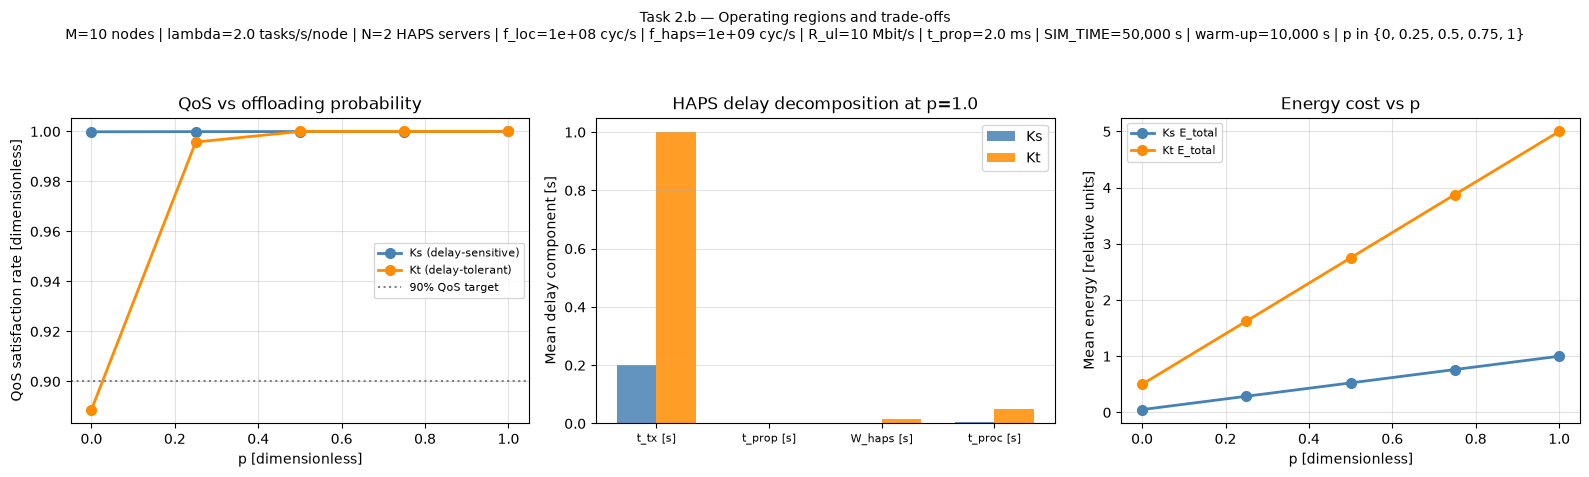

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

# Task 2.b — QoS, delay decomposition, energy
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for tc, c in colors.items():
    axes[0].plot(P_VALUES, results[tc]['qos_rate'], 'o-', color=c, lw=2, ms=7, label=labels[tc])
axes[0].axhline(0.9, color='gray', ls=':', label='90% QoS target')
axes[0].set_xlabel('p [dimensionless]')
axes[0].set_ylabel('QoS satisfaction rate [dimensionless]')
axes[0].set_title('QoS vs offloading probability')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.35)

p1_idx = -1
x = np.arange(4)
width = 0.35
comp = ['d_tx', 'd_prop', 'd_wq', 'd_proc']
comp_lbl = ['t_tx [s]', 't_prop [s]', 'W_haps [s]', 't_proc [s]']
for i, tc in enumerate(['Ks', 'Kt']):
    vals = [results[tc][k][p1_idx] for k in comp]
    axes[1].bar(x + i * width, vals, width, label=tc, color=colors[tc], alpha=0.85)
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(comp_lbl, fontsize=8)
axes[1].set_ylabel('Mean delay component [s]')
axes[1].set_title('HAPS delay decomposition at p=1.0')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.35)

for tc, c in colors.items():
    axes[2].plot(P_VALUES, results[tc]['E_total'], 'o-', color=c, lw=2, ms=7, label=f'{tc} E_total')
axes[2].set_xlabel('p [dimensionless]')
axes[2].set_ylabel('Mean energy [relative units]')
axes[2].set_title('Energy cost vs p')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.35)

fig.suptitle(f"Task 2.b — Operating regions and trade-offs\n{CFG}", fontsize=10, y=1.05)
plt.tight_layout()
plt.savefig('task2b_regions.png', dpi=150, bbox_inches='tight')
plt.show()



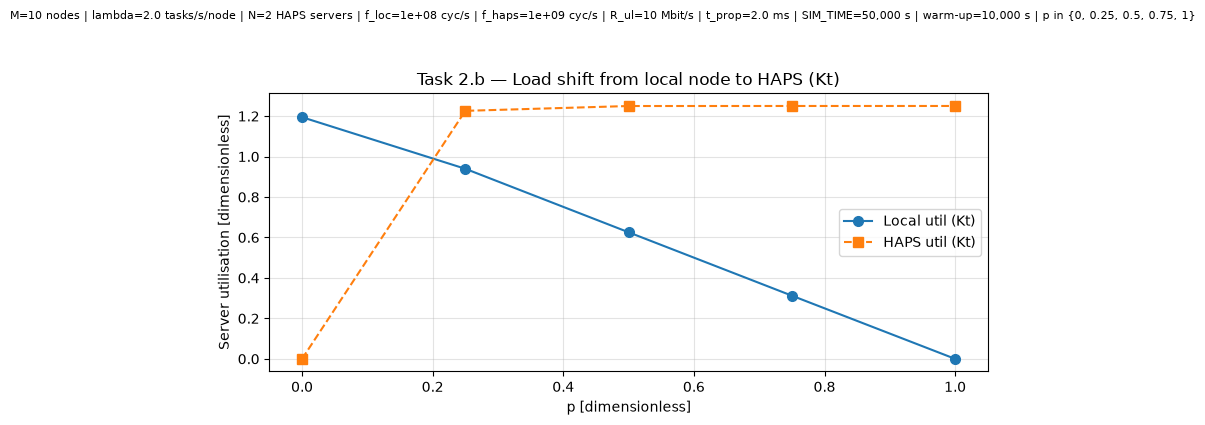

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

# Task 2.b — utilisation (Kt)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(P_VALUES, results['Kt']['loc_util'], 'o-', ms=7, label='Local util (Kt)')
ax.plot(P_VALUES, results['Kt']['hap_util'], 's--', ms=7, label='HAPS util (Kt)')
ax.set_xlabel('p [dimensionless]')
ax.set_ylabel('Server utilisation [dimensionless]')
ax.set_title('Task 2.b — Load shift from local node to HAPS (Kt)')
ax.legend()
ax.grid(True, alpha=0.35)
fig.suptitle(CFG, fontsize=8, y=1.05)
plt.tight_layout()
plt.savefig('task2b_utilisation.png', dpi=150, bbox_inches='tight')
plt.show()



## Task 2.b — Operating Regions and Trade-offs

Task 2.b maps the simulation results onto the two coupled queues in the system: the local M/M/1 per node and the shared HAPS pool. Increasing $p$ always trades local load for HAPS load — $\rho_{\mathrm{loc}}$ scales down by $(1-p)$ while $\rho_{\mathrm{haps}}$ grows with $p$. Whether that trade is beneficial depends on which side is closer to saturation and how expensive the uplink is for each task class.

### Where offloading helps and where it hurts

For **Ks**, the beneficial region for delay is essentially empty. The local node starts underloaded, so shifting work to the HAPS cannot shorten queues — it only forces tasks onto a path where transmission time outweighs the faster HAPS compute. The QoS and energy plots reinforce this: performance stays acceptable at all $p$, but both metrics are best at $p=0$.

For **Kt**, the picture reverses. At $p=0$ the system sits in a **local-collapse** region: the node is permanently busy, drops appear, and QoS suffers. Once $p$ reaches about 0.25, enough load moves off the local queue that QoS recovers quickly. Delay then keeps improving through the **hybrid** range ($p \approx 0.5$–$0.75$), where local queues are short but not every task pays the full uplink penalty. At $p=1$, QoS is still perfect, but the system enters a **communication-limited** region — congestion is gone, yet delay is bounded from below by $t_{\mathrm{tx}}$.

Decomposing the HAPS path at $p=1$ explains why: for Kt, transmission accounts for most of the remote completion time, while HAPS queueing stays negligible because $\rho_{\mathrm{haps}}$ remains moderate. For Ks, the same decomposition shows the opposite — the compute saving on the HAPS is too small to justify the uplink cost.

### Energy and load migration

The energy curves rise roughly linearly with $p$ for both classes, since each offloaded task adds a fixed transmission cost proportional to payload size $L$. For Ks, this again favours $p=0$. For Kt, higher $p$ costs more energy, but the delay and reliability gains at $p=0.75$ are large enough to justify the trade-off in a QoS-constrained setting.

The utilisation plot for Kt makes the mechanism visible: as $p$ grows, local utilisation falls from saturation toward idle, while HAPS utilisation climbs smoothly to about half capacity at full offload. The delay minimum near $p=0.75$ aligns with the point where enough work has migrated to relieve the local bottleneck without overloading the shared edge.

### Conclusion

Offloading is beneficial when local congestion is the binding problem and the communication tax is still acceptable — exactly the Kt case. When the local node is already stable and payloads are small, offloading is detrimental on both delay and energy, which is what we see for Ks.


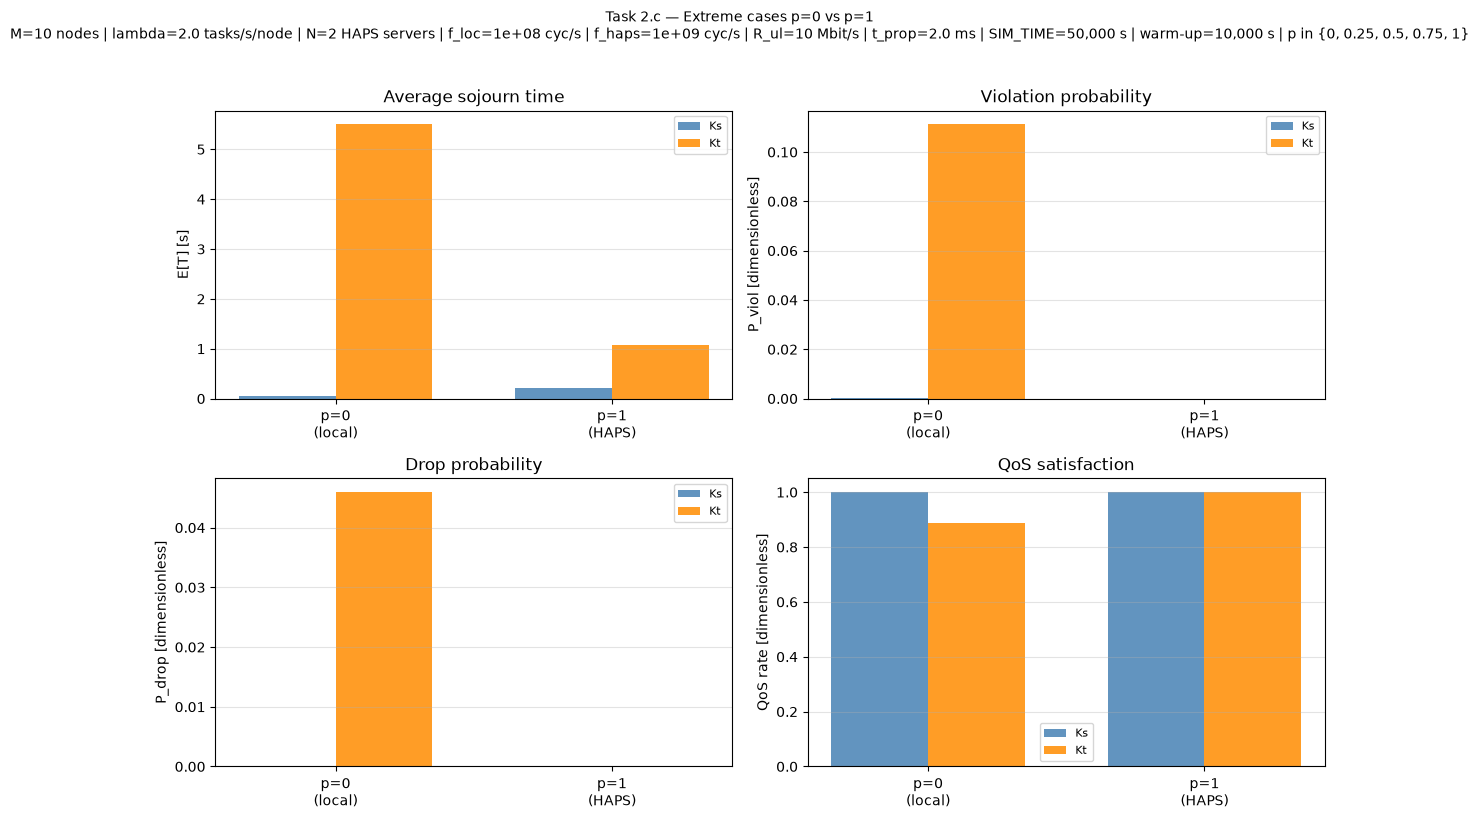

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# Task 2.c — p=0 vs p=1
ext = {tc: {k: [results[tc][k][0], results[tc][k][-1]] for k in KEYS} for tc in ['Ks', 'Kt']}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
bar_sets = [
    ('ET_avg',    'E[T] [s]',               'Average sojourn time'),
    ('viol_prob', 'P_viol [dimensionless]', 'Violation probability'),
    ('drop_prob', 'P_drop [dimensionless]', 'Drop probability'),
    ('qos_rate',  'QoS rate [dimensionless]','QoS satisfaction'),
]
x = np.arange(2)
w = 0.35
xt = ['p=0\n(local)', 'p=1\n(HAPS)']
for ax, (key, ylab, title) in zip(axes.flat, bar_sets):
    for i, tc in enumerate(['Ks', 'Kt']):
        ax.bar(x + i * w, ext[tc][key], w, label=tc, color=colors[tc], alpha=0.85)
    ax.set_xticks(x + w / 2)
    ax.set_xticklabels(xt)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.35)
fig.suptitle(f"Task 2.c — Extreme cases p=0 vs p=1\n{CFG}", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('task2c_extremes.png', dpi=150, bbox_inches='tight')
plt.show()



In [6]:
# Task 2.c — comparison table
print("\n=== Task 2.c comparison table ===")
print(f"{'Class':<4} {'Case':<6} | {'E[T]':>7} | {'QoS':>6} | {'Drop':>6} | {'TP':>6}")
for tc in ['Ks', 'Kt']:
    for label, idx in [('p=0', 0), ('p=1', -1)]:
        print(
            f"{tc:<4} {label:<6} | {results[tc]['ET_avg'][idx]:>7.3f} | "
            f"{results[tc]['qos_rate'][idx]:>6.3f} | {results[tc]['drop_prob'][idx]:>6.3f} | "
            f"{results[tc]['throughput'][idx]:>6.3f}"
        )




=== Task 2.c comparison table ===
Class Case   |    E[T] |    QoS |   Drop |     TP
Ks   p=0    |   0.055 |  1.000 |  0.000 | 19.998
Ks   p=1    |   0.207 |  1.000 |  0.000 | 19.976
Kt   p=0    |   5.502 |  0.889 |  0.046 | 19.101
Kt   p=1    |   1.069 |  1.000 |  0.000 | 20.014


## Task 2.c — Extreme Cases: $p=0$ vs $p=1$

Comparing the two extremes makes the role of $p$ clearer than the full sweep alone. The bar charts and comparison table show the same underlying split: **Ks** is already healthy locally, while **Kt** is in crisis at $p=0$ but recoverable once work is moved to the HAPS.

### Full local processing ($p=0$)

For Ks, keeping everything local works well. Simulated delay matches the lightly loaded M/M/1 expectation, throughput is nominal, and there are no drops. The local node simply has enough capacity for this task size and arrival rate, so there is nothing for offloading to fix.

For Kt, full local processing fails in practice. The server runs at critical utilisation, queueing blows up completion time far above mean service time, and the finite local buffer starts dropping tasks. Throughput falls below the offered load and QoS drops below 90 % despite the generous deadline. This confirms that the problem at $p=0$ is local saturation, not insufficient HAPS capacity.

### Full offloading ($p=1$)

Sending all Ks traffic to the HAPS is feasible — QoS remains perfect because the HAPS is lightly loaded — but average delay increases sharply compared with $p=0$. Every task now pays the uplink even though the local queue was never congested, so full offload is workable but clearly wasteful.

For Kt, full offload fixes the reliability problem: drops disappear, throughput returns to nominal, and QoS reaches 100 %. However, delay is no longer queue-limited; it is dominated by transmission time. That is why $p=1$ is better than $p=0$ but still slightly worse than the hybrid optimum found in Task 2.a, where only part of the traffic pays the uplink cost.

### Recommendations

Neither extreme is universally best. **Ks** should stay at **$p=0$** because the local path is faster, cheaper, and already QoS-compliant. **Kt** needs offloading, but **$p \approx 0.75$** is preferable to full offload: it removes local congestion while avoiding the penalty of sending every heavy task over the uplink.

### Conclusion

The extremes highlight a simple design rule: offload when local congestion hurts more than the communication cost. For light, delay-sensitive tasks that rule points to local processing; for heavy, overloaded tasks it points to a balanced hybrid strategy rather than all-or-nothing offloading.
